# Libraries and Functions

In [48]:
import pandas as pd
import numpy as np

import pickle

from sympy import Basic
from joblib import Parallel, delayed
from tqdm import tqdm
from symbolic_regression.utils.visualization import plot_results

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [ ]:
def get_final_expr(
    dataset_equations: dict[str, list],
    method: str,
    run_idx: int
) -> Basic:
    """
    Extracts the final SymPy expression for a given method and run.

    For the 'RFGPCMI' method, it returns the sum of the final sub-expressions. 
    For all other methods, it returns the single final expression.

    Parameters
    ----------
    dataset_equations : dict[str, list]
        A dictionary containing the equations for a dataset, keyed by method name.
    method : str
        The name of the symbolic regression method (e.g., 'GP', 'RFGPCMI').
    run_idx : int
        The index of the execution run to extract the expression from.

    Returns
    -------
    Basic
        The final SymPy expression.
    """

    if method != "RFGPCMI":
        return dataset_equations [method][run_idx][-1].sympy_format
    
    else:
        return sum(
            sub_expr[-1].sympy_format 
            for sub_expr in dataset_equations [method][run_idx]
        ) # type: ignore

def tree_size(
    expr: Basic,
    weights: dict[type, int | float] | None = None,
    default_weight: int | float = 1
) -> int | float:
    """
    Compute the size of a SymPy expression tree.

    Each node in the tree contributes a weight to the total size. The weight
    of a node is determined by its type, using the first match found in
    ``weights`` after sorting by MRO depth (most specific type first).

    Parameters
    ----------
    expr : sympy.Basic
        The SymPy expression whose tree size is to be computed.
    weights : dict[type, int | float], optional
        A mapping from SymPy types to their corresponding weights.
        More specific types (deeper in the class hierarchy) take precedence
        over more general ones, regardless of insertion order.
        If None, all nodes use ``default_weight``.
    default_weight : int or float, optional
        The weight assigned to any node whose type is not found in
        ``weights``. Default is 1.

    Returns
    -------
    int or float
        The total weighted size of the expression tree.
    """

    if weights is None: weights = {}

    # Sort by MRO length descending so that more specific types (e.g. One)
    # are matched before more general ones (e.g. Integer).
    # We do this ONCE outside the recursion for better performance.
    sorted_weights = sorted(
        weights.items(),
        key=lambda kv: len(kv[0].__mro__),
        reverse=True
    )

    # Compute the size of the tree recursively.
    def _compute_size(
        node: Basic,
    ) -> int | float:
        node_weight = default_weight

        for node_type, w in sorted_weights:
            if isinstance(node, node_type):
                node_weight = w
                break  # Stop at the first (most specific) match.

        # Recursively accumulate the weight of this node and all its children.
        return node_weight + sum(_compute_size(arg) for arg in node.args)

    return _compute_size(expr)

def remove_suffix_recursively(
    data: str | list | dict | tuple | set,
    suffix: str
) -> str | list | dict | tuple | set:
    """
    Recursive function that traverses lists, dictionaries, tuples, and sets
    to clean the contained strings.

    Parameters
    ----------
    data : str | list | dict | tuple | set
        The data structure to clean.
    suffix : str
        The suffix to remove from strings. For example, if the suffix is "_f2",
        then "X_f2" would become "X".

    Returns
    -------
    str | list | dict | tuple | set
        The cleaned data structure with the suffix removed from all strings.
    """

    if isinstance(data, str):
        return data.removesuffix(suffix)
    elif isinstance(data, list):
        return [remove_suffix_recursively(item, suffix) for item in data]
    elif isinstance(data, tuple):
        return tuple(remove_suffix_recursively(item, suffix) for item in data)
    elif isinstance(data, set):
        return {remove_suffix_recursively(item, suffix) for item in data} # type: ignore
    elif isinstance(data, dict):
        return {key: remove_suffix_recursively(val, suffix) for key, val in data.items()}
    else:
        return data  # Return as is if it's not a supported iterable/iterable type

# Data Preprocessing

In [3]:
# Load synthetic dataset results
with open("data_synthetic.pkl", "rb") as f:
    synth = pickle.load(f)['kwargs']

results_df, features, equations = synth['df'], synth['features'], synth['equations']

# Reorder MultiIndex columns for consistent plotting
order = {
    'dataset': ['F1', 'F2', 'Friedman1', 'Friedman2', 'Friedman3'],
    'method':  ['GPPI', 'GPSHAP', 'GPCMI', 'RFGPCMI', 'GP'],
    'metric':  ['training_losses', 'validation_losses', 'test_losses']
}

for level, cols in order.items():
    results_df = results_df.reindex(columns=cols, level=level)

# Remove dataset suffixes from feature names for cleaner display
for ds in features:
    features[ds] = remove_suffix_recursively(features[ds], f"_{ds.lower()}")
    features[ds] = remove_suffix_recursively(features[ds], f"_{ds.upper()}")

results_df.tail(3)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


dataset                F1                                                \
method               GPPI                                        GPSHAP   
metric    training_losses validation_losses test_losses training_losses   
run epoch                                                                 
99  80           0.000002          0.000004    0.000003        0.000005   
    90           0.000003          0.000003    0.000003        0.000005   
    100          0.000003          0.000003    0.000003        0.000005   

dataset                                                                    \
method                                            GPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  80             0.000005    0.000005        0.000341          0.000363   
    90             0.000008    0.000005        0.000303          0.000475   
    100            0.000006    0.000005        0.000060          0.000086   

dataset                                ...   Friedman3                  \
method                        RFGPCMI  ...      GPSHAP           GPCMI   
metric    test_losses training_losses  ... test_losses training_losses   
run epoch                              ...                               
99  80       0.000297        0.014686  ...    0.092967        0.018662   
    90       0.000297        0.008794  ...    0.092632        0.018776   
    100      0.000063        0.020980  ...    0.092820        0.018596   

dataset                                                                    \
method                                          RFGPCMI                     
metric    validation_losses test_losses training_losses validation_losses   
run epoch                                                                   
99  80             0.018715    0.020996        0.019016          0.017662   
    90             0.018658    0.020996        0.019016          0.017662   
    100            0.019213    0.020996        0.019016          0.017662   

dataset                                                              
method                             GP                                
metric    test_losses training_losses validation_losses test_losses  
run epoch                                                            
99  80       0.021002        0.018668          0.018802    0.020996  
    90       0.021002        0.018764          0.018926    0.020996  
    100      0.021002        0.018740          0.018393    0.020996  

[3 rows x 75 columns]

In [45]:
num_runs = len(equations[order['dataset'][0]][order['method'][0]])

# Define the true equations as strings for each dataset
true_equations_str = {
    "F1": "-6.67408e-11 * (X1 * X2) / X3**2",
    "F2": "30 * X1 * X3 / ((X1 - 10) * X2**2)",
    "Friedman1": "10 * sin(pi * X1 * X2) + 20 * (X3 - 0.5)**2 + 10 * X4 + 5 * X5",
    "Friedman2": "sqrt( X1**2 + (X2 * X3 - 1 / (X2 * X4))**2 )",
    "Friedman3": "atan((X2 * X3 - 1 / (X2 * X4)) / X1)"
}

# Predictive Performance

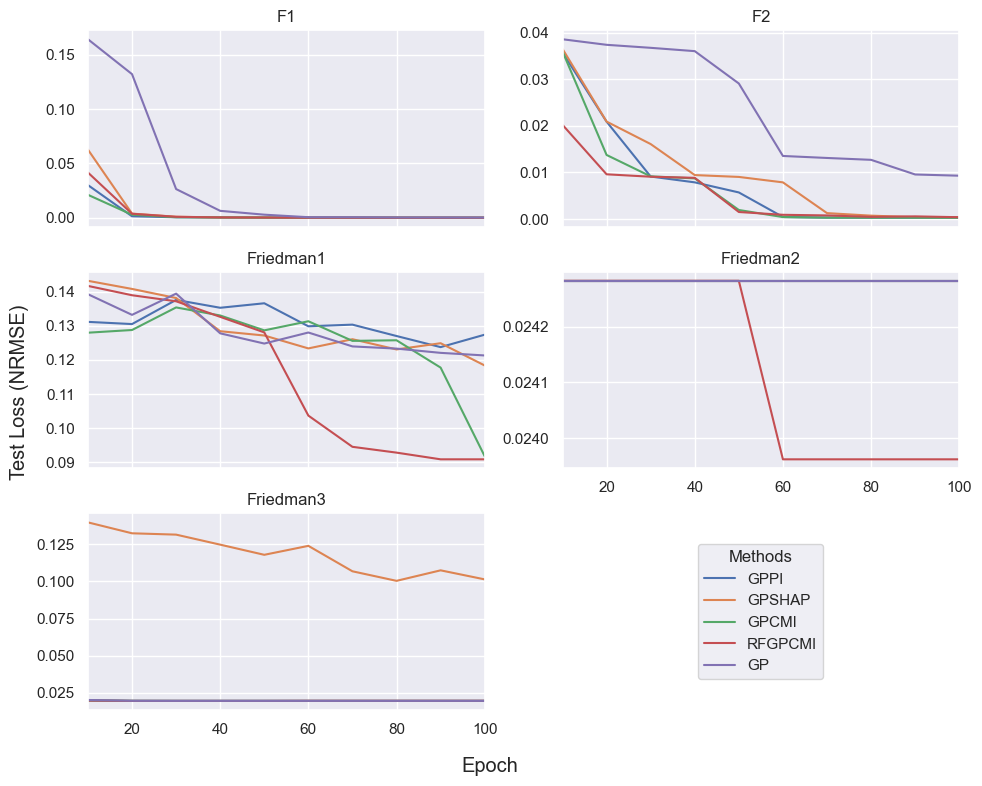

In [4]:
# Plotting test losses for each dataset and method per epoch
fig, axes = plot_results(
    results_df.groupby(level='epoch').median(), 
    nrows=3, 
    ncols=2,
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric",
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.lineplot(data=data, ax=ax, dashes=None)
)

# Set X and Y label for the entire figure
fig.supxlabel("Epoch", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[0].set_xlim(10, 100) # Set x-axis limits to show all epochs
axes[4].set_xlabel("") # Hide the x-label
axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Remove legends from individual subplots
for ax in axes[:5]: ax.get_legend().remove()

# Take the legend handles and labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center',
    title="Methods"
)

plt.show()

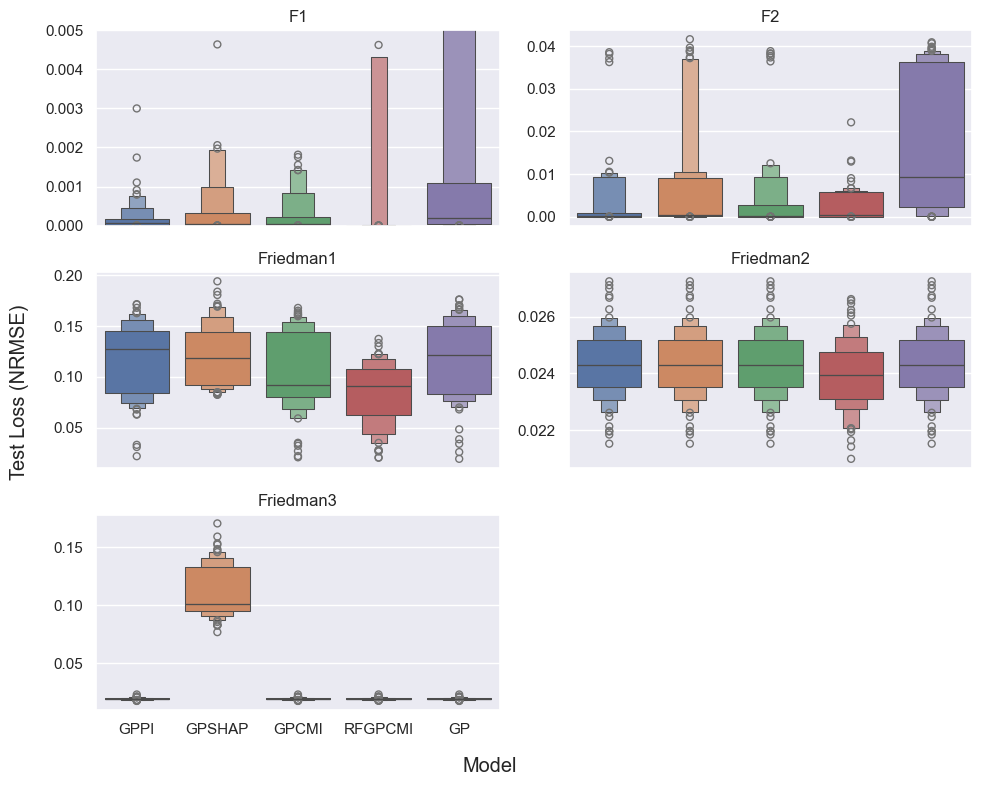

In [14]:
# Plotting test losses for each dataset and method at the last epoch
fig, axes = plot_results(
    results_df.groupby(level='run').last(), 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.boxenplot(data=data, ax=ax)
)

# Set X and Y label for the entire figure
fig.supxlabel("Model", x=0.5, y=0.02)
fig.supylabel("Test Loss (NRMSE)", x=0.02, y=0.5)

axes[0].set_ylim(0, 0.005) # Set y-axis limits to zoom in on the boxenplots

plt.show()

In [6]:
# Calculate median test losses for each method and dataset at the last epoch
median_loss = results_df.groupby(level='run').last().median()
gp_median_loss = median_loss[:, "GP", :]

# Extract the list of methods excluding "GP" for comparison
methods = results_df.columns.levels[1].to_list()
methods.remove("GP")

# Extract the median losses for the competitor methods
competitor_median_loss = median_loss.loc[:, methods, :]

# Calculate relative improvement of GP over competitors for each dataset and metric
relative_improvement = (gp_median_loss - competitor_median_loss) * 100 / gp_median_loss
relative_improvement_df = relative_improvement.to_frame().T

# Reorder the relative improvement DataFrame to match the desired column order for plotting
relative_improvement_df = relative_improvement_df.swaplevel('metric', 'method', axis=1)
relative_improvement_df = relative_improvement_df.reindex(columns=order['dataset'], level='dataset')
relative_improvement_df = relative_improvement_df.reindex(columns=methods, level='method')
relative_improvement_df = relative_improvement_df.reindex(columns=order['metric'], level='metric')
relative_improvement_df

dataset              F1                                                \
method             GPPI                                        GPSHAP   
metric  training_losses validation_losses test_losses training_losses   
0              69.84111         68.186421   66.413677       78.901664   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0                72.34724   73.883448       84.991093         81.392961   

dataset                              ...   Friedman3                  \
method                      RFGPCMI  ...        GPPI          GPSHAP   
metric  test_losses training_losses  ... test_losses training_losses   
0         81.659979       99.938247  ...         0.0     -406.190749   

dataset                                                                  \
method                                          GPCMI                     
metric  validation_losses test_losses training_losses validation_losses   
0             -426.886721  -419.89395        0.590635         -1.331246   

dataset                                                            
method                      RFGPCMI                                
metric  test_losses training_losses validation_losses test_losses  
0               0.0        0.349747           0.98888   -0.315091  

[1 rows x 60 columns]

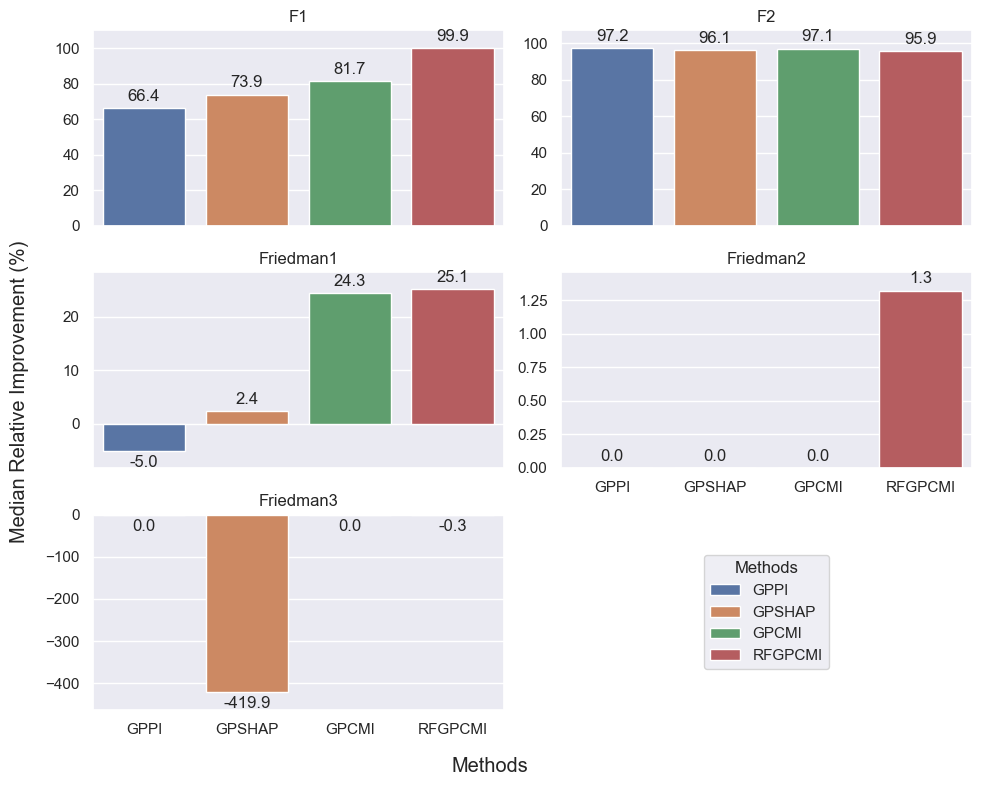

In [ ]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_improvement_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True, "figsize": (10, 8), "layout": "tight"},
    group_level="dataset",
    value_level="metric", 
    value_key="test_losses",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

# Set X and Y label for the entire figure
fig.supxlabel("Methods", x=0.5, y=0.02)
fig.supylabel("Median Relative Improvement (%)", x=0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True) # Restore x-tick labels

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.1f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods"
)

plt.show()

# Model Complexity

In [ ]:
from sympy import parse_expr

# Parse the true equations into SymPy expressions
true_equations_expr = {
    name: parse_expr(eq_str)
    for name, eq_str in true_equations_str.items()
}

# Calculate true tree sizes for each dataset using the true equations
true_sizes = {
    dataset: tree_size(expr)
    for dataset, expr in true_equations_expr.items()
}

In [ ]:
# Calculate tree sizes for each run, method, and dataset in parallel using joblib
tree_sizes = {}
for ds in order['dataset']:
    tree_sizes[ds] = {}

    for m in order['method']:
        tree_sizes[ds][m] = Parallel(n_jobs=-1)(
            delayed(tree_size)(
                get_final_expr(equations[ds], m, run).simplify() 
            ) for run in tqdm(range(num_runs), desc=f"Calculating tree sizes for {ds} - {m}")  
        )

Calculating tree sizes for Friedman3 - GP: 100%|██████████| 100/100 [00:00<00:00, 460.18it/s]


In [34]:
# Create a DataFrame to store tree sizes with MultiIndex columns for dataset and method
tree_sizes_column_order = pd.MultiIndex.from_product([order['dataset'], order['method']], names=['dataset', 'method'])

tree_sizes_df = pd.concat(
    {ds: pd.DataFrame(tree_sizes[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=tree_sizes_column_order)
tree_sizes_df.index.name = "run"
tree_sizes_df.tail(3)

dataset   F1                           F2                           ...  \
method  GPPI GPSHAP GPCMI RFGPCMI GP GPPI GPSHAP GPCMI RFGPCMI  GP  ...   
run                                                                 ...   
97         7      7     7       7  7   10     14    12      16  26  ...   
98         7      7     7       7  7   14     12    12      35   9  ...   
99         7      7     7      13  7   14     12    14      16   4  ...   

dataset Friedman2                         Friedman3                          
method       GPPI GPSHAP GPCMI RFGPCMI GP      GPPI GPSHAP GPCMI RFGPCMI GP  
run                                                                          
97              3      3     3      15  3         7      7     7       9  7  
98              3      3     3       5  3         7      7     7       9  7  
99              3      3     3       5  3         7      7     7       9  7  

[3 rows x 25 columns]

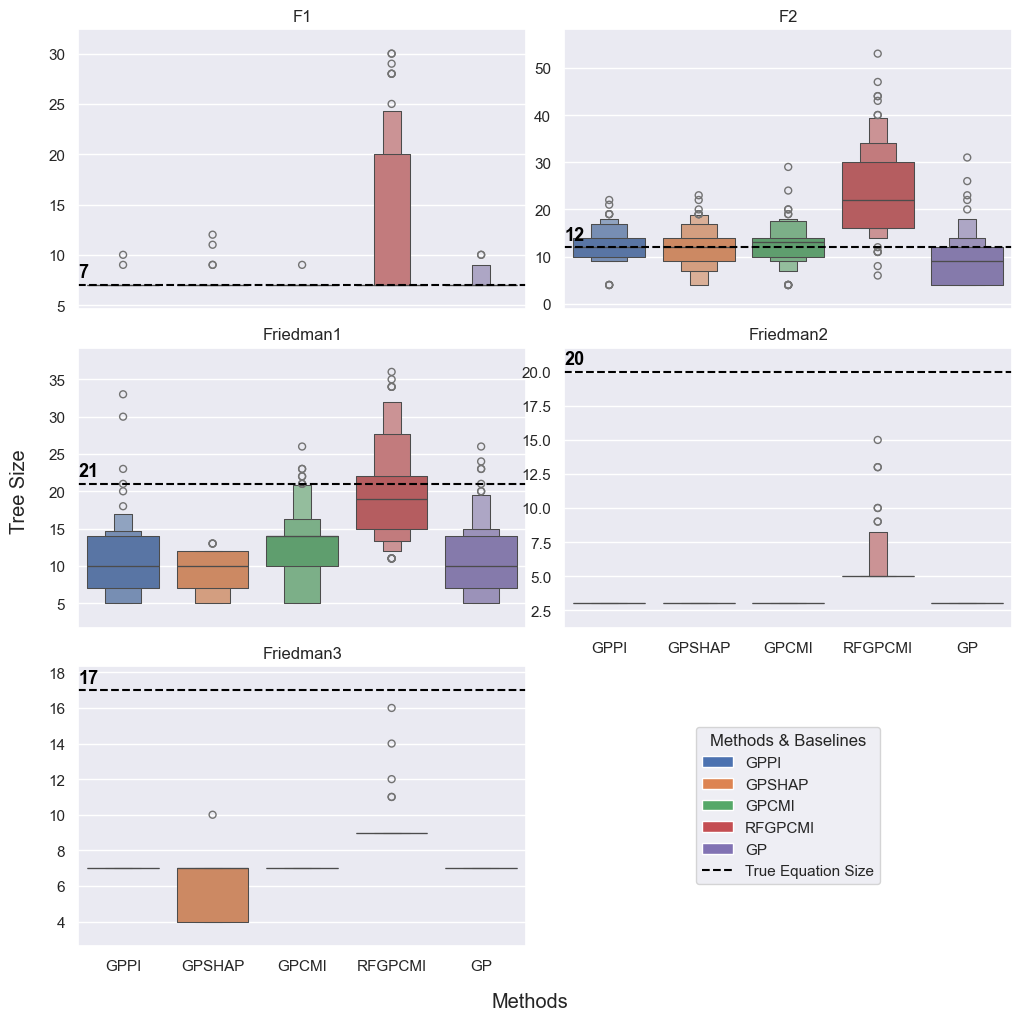

In [36]:
from matplotlib.patches import Patch

# Plotting tree sizes for each dataset and method at the last epoch
fig, axes = plot_results(
    tree_sizes_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.boxenplot(data=data, ax=ax),
)

fig.figure.set_size_inches(10, 10)
fig.tight_layout(w_pad=0.5)

fig.supxlabel("Methods", x=0.5, y=-0.02)
fig.supylabel("Tree Size", x=-0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True)
axes[5].axis('off')

# # Add value labels on top of each bar, adjust y-axis limits, and add true value lines
for ax in axes[:5]:
    margin_ratio = 0.05
    text_offset_ratio = 0.03
    fontsize = 13

    dataset_name = ax.get_title()
    true_value = true_sizes[dataset_name]

    ax.axhline(
        y=true_value, 
        color='black', 
        linestyle='--', 
        linewidth=1.5,
        label='True Equation Size'
    )

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    ax.text(
        ax.get_xlim()[0], 
        true_value + text_offset_ratio * (top - bottom),
        f'{true_value}', 
        color='black',
        fontweight='bold',
        fontsize=fontsize,
    )

handle, label = axes[4].get_legend_handles_labels()
colors = sns.color_palette(n_colors=len(order['method']))
handles = [Patch(facecolor=c) for c in colors] + handle
labels = order['method'].copy() + label

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods & Baselines"
)

plt.show()

# Feature Selection Analysis

In [37]:
true_features_per_dataset = {
    dataset_name: {
        str(symbol) for symbol in equation.free_symbols
    } for dataset_name, equation in true_equations_expr.items()
}

total_irrelevant_features = {
    dataset_name: len(features[dataset_name]["GP"][0]) - len(true_features_per_dataset[dataset_name])
    for dataset_name in order['dataset']
}

true_features_per_dataset

{'F1': {'X1', 'X2', 'X3'},
 'F2': {'X1', 'X2', 'X3'},
 'Friedman1': {'X1', 'X2', 'X3', 'X4', 'X5'},
 'Friedman2': {'X1', 'X2', 'X3', 'X4'},
 'Friedman3': {'X1', 'X2', 'X3', 'X4'}}

In [39]:
selection_rates = {}
num_runs = len(equations[order['dataset'][0]][order['method'][0]])

for dataset_name in order['dataset']:
    selection_rates[dataset_name] = {}

    for method_name in order['method']:
        selection_rates[dataset_name][method_name] = {
            "relevant": np.empty(num_runs),
            "irrelevant": np.empty(num_runs)
        }
        features_selected = features[dataset_name][method_name]

        for run_idx in range(num_runs): 
            if method_name == "RFGPCMI":
                selected_features = set()

                for feature_list in features_selected[run_idx]:
                    selected_features.update(feature_list)

            else:
                selected_features = set(features_selected[run_idx])

            true_features = true_features_per_dataset[dataset_name]
            correctly_selected = len(selected_features & true_features)
            falsely_selected = len(selected_features - true_features)
            
            selection_rates[dataset_name][method_name]["relevant"][run_idx] = correctly_selected / len(true_features)
            selection_rates[dataset_name][method_name]["irrelevant"][run_idx] = falsely_selected / len(selected_features)

In [41]:
selection_rate_types = ['relevant', 'irrelevant']
selection_rate_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method'], selection_rate_types], names=['dataset', 'method', 'rate_type']
)

selection_rate_df = pd.concat(
    {
        (ds, method): pd.DataFrame(selection_rates[ds][method])
        for ds in order['dataset']
        for method in order['method']
    },
    axis=1,
).reindex(columns=selection_rate_column_order)
selection_rate_df.index.name = "run"
selection_rate_df.tail(3)

dataset         F1                                                     \
method        GPPI              GPSHAP               GPCMI              
rate_type relevant irrelevant relevant irrelevant relevant irrelevant   
run                                                                     
97             1.0        0.0      1.0        0.5      1.0       0.00   
98             1.0        0.0      1.0        0.5      1.0       0.25   
99             1.0        0.0      1.0        0.5      1.0       0.50   

dataset                                            ... Friedman3             \
method     RFGPCMI                  GP             ...      GPPI              
rate_type relevant irrelevant relevant irrelevant  ...  relevant irrelevant   
run                                                ...                        
97             1.0       0.00      1.0   0.943396  ...      0.75        0.0   
98             1.0       0.25      1.0   0.943396  ...      0.75        0.0   
99             1.0       0.50      1.0   0.943396  ...      0.75        0.0   

dataset                                                                \
method      GPSHAP               GPCMI             RFGPCMI              
rate_type relevant irrelevant relevant irrelevant relevant irrelevant   
run                                                                     
97             0.5        0.0     0.75        0.0     0.75        0.0   
98             0.5        0.0     0.75        0.0     0.75        0.0   
99             0.5        0.0     0.75        0.0     0.75        0.0   

dataset                        
method          GP             
rate_type relevant irrelevant  
run                            
97             1.0        0.0  
98             1.0        0.0  
99             1.0        0.0  

[3 rows x 50 columns]

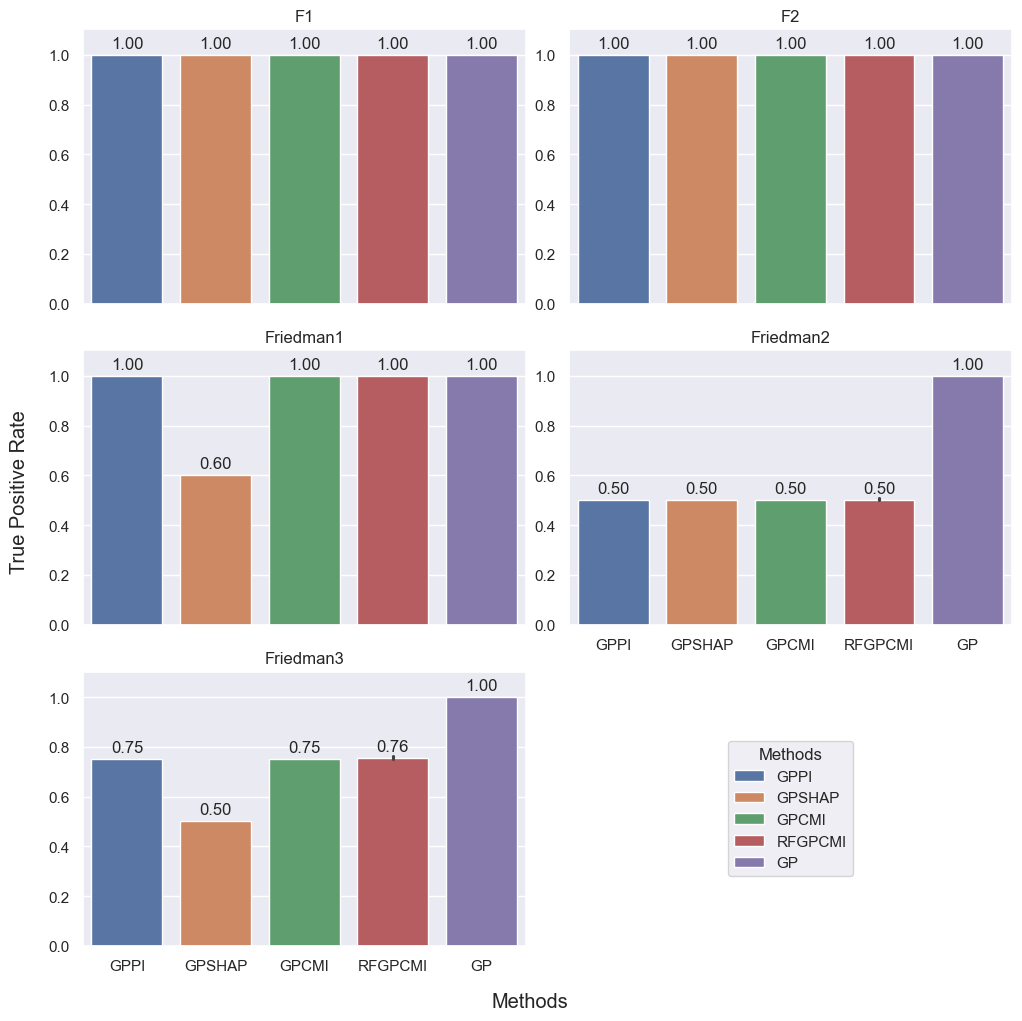

In [42]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    selection_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True},
    group_level="dataset",
    value_level="rate_type", 
    value_key="relevant",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

fig.figure.set_size_inches(10, 10)
fig.tight_layout(w_pad=0.5)

fig.supxlabel("Methods", x=0.5, y=-0.02)
fig.supylabel("True Positive Rate", x=-0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True)
axes[5].axis('off')

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods"
)

plt.show()

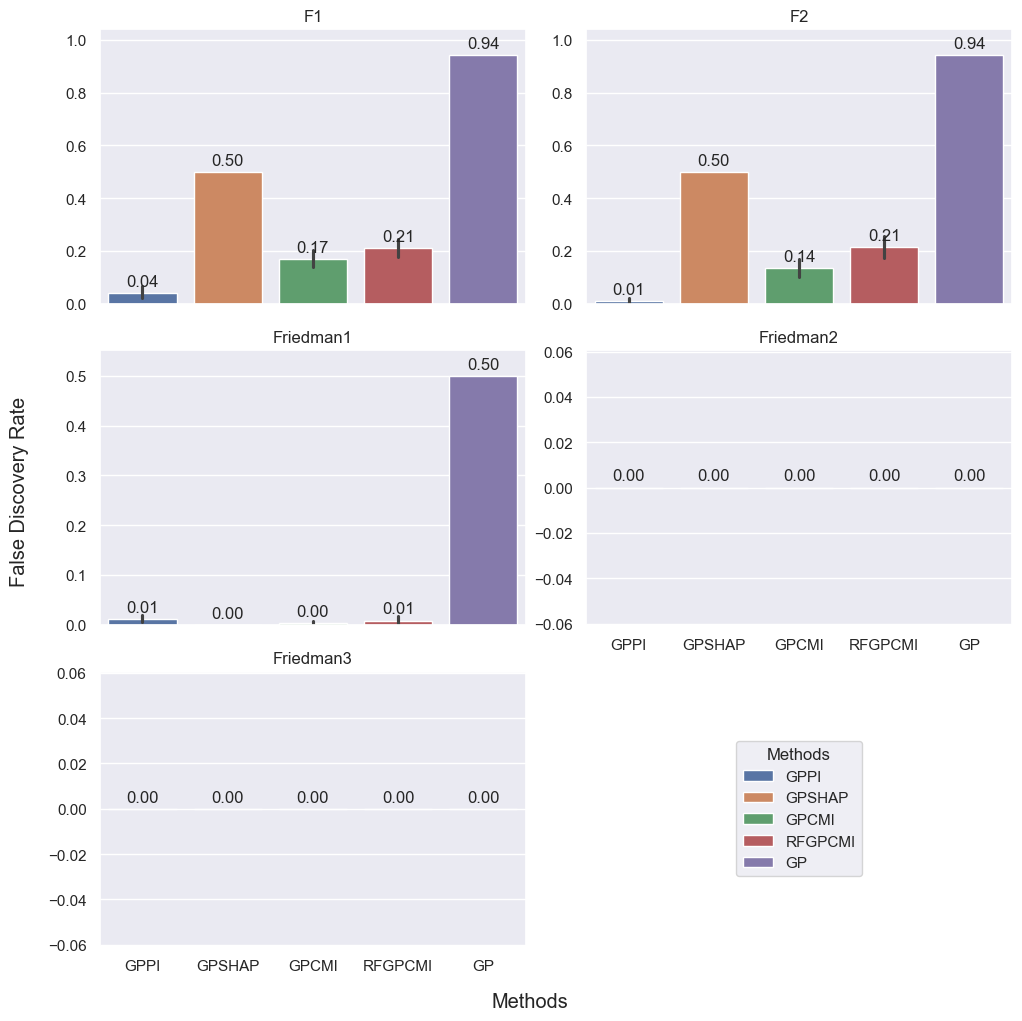

In [43]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    selection_rate_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True},
    group_level="dataset",
    value_level="rate_type", 
    value_key="irrelevant",
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

fig.figure.set_size_inches(10, 10)
fig.tight_layout(w_pad=0.5)

fig.supxlabel("Methods", x=0.5, y=-0.02)
fig.supylabel("False Discovery Rate", x=-0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True)
axes[5].axis('off')

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods"
)

plt.show()

# Computational Efficiency

In [50]:
from symbolic_regression.utils.io_utils import load_pickle_files

times_dict = {}
for dataset_name in order['dataset']:
    times_dict[dataset_name] = {}
    
    for method_name in order['method']:
        folder = f"data/synthetic_params/{dataset_name}/{method_name}/"
        loaded = load_pickle_files(folder)

        times_dict[dataset_name][method_name] = np.array(
            [run_data['metadata']['execution_duration_seconds'] for run_data in loaded]
        )
        print(f"Loaded data for {dataset_name} - {method_name}")

Loaded data for F1 - GPPI
Loaded data for F1 - GPSHAP
Loaded data for F1 - GPCMI
Loaded data for F1 - RFGPCMI
Loaded data for F1 - GP
Loaded data for F2 - GPPI
Loaded data for F2 - GPSHAP
Loaded data for F2 - GPCMI
Loaded data for F2 - RFGPCMI
Loaded data for F2 - GP
Loaded data for Friedman1 - GPPI
Loaded data for Friedman1 - GPSHAP
Loaded data for Friedman1 - GPCMI
Loaded data for Friedman1 - RFGPCMI
Loaded data for Friedman1 - GP
Loaded data for Friedman2 - GPPI
Loaded data for Friedman2 - GPSHAP
Loaded data for Friedman2 - GPCMI
Loaded data for Friedman2 - RFGPCMI
Loaded data for Friedman2 - GP
Loaded data for Friedman3 - GPPI
Loaded data for Friedman3 - GPSHAP
Loaded data for Friedman3 - GPCMI
Loaded data for Friedman3 - RFGPCMI
Loaded data for Friedman3 - GP


In [51]:
time_column_order = pd.MultiIndex.from_product(
    [order['dataset'], order['method']], names=['dataset', "method"]
)

time_df = pd.concat({ds: pd.DataFrame(times_dict[ds]) for ds in order['dataset']},
    axis=1,
).reindex(columns=time_column_order)
time_df.index.name = "run"
time_df.tail(3)

dataset          F1                                                       F2  \
method         GPPI      GPSHAP      GPCMI    RFGPCMI         GP        GPPI   
run                                                                            
97       507.880250  703.115191  22.859204  28.203976  23.636042  914.089561   
98       486.720471  699.807413  25.777269  27.644862  24.917989  930.289924   
99       503.321620  673.807707  29.116298  26.518790  22.138918  910.351331   

dataset                                                ...    Friedman2  \
method        GPSHAP      GPCMI    RFGPCMI         GP  ...         GPPI   
run                                                    ...                
97       1275.755898  44.556575  75.288406  23.469010  ...  1109.075604   
98       1338.350543  44.174995  67.043867  23.762460  ...  1115.135361   
99       1299.855674  55.518058  65.482201  24.481523  ...  1056.677148   

dataset                                                Friedman3              \
method       GPSHAP      GPCMI    RFGPCMI         GP        GPPI      GPSHAP   
run                                                                            
97       867.533791  44.819208  23.354113  33.794512  744.091345  890.249166   
98       914.333592  45.928801  22.906844  34.464759  741.020790  915.489294   
99       884.758213  45.577174  23.347079  34.444509  760.914362  910.738485   

dataset                                   
method       GPCMI    RFGPCMI         GP  
run                                       
97       57.363376  32.118049  42.169491  
98       75.171699  30.936642  42.175099  
99       61.423503  31.169561  42.418022  

[3 rows x 25 columns]

In [53]:
# Calculate median relative time for each method and dataset
median_run_relative_time = time_df.median()
gp_median_time = median_run_relative_time[:, "GP", :]

methods = order['method'].copy()
methods.remove("GP")

competitor_median_time = median_run_relative_time.loc[:, methods, :]

relative_time = competitor_median_time / gp_median_time
relative_time_df = relative_time.to_frame().T

relative_time_df = relative_time_df.reindex(columns=order['dataset'], level='dataset')
relative_time_df = relative_time_df.reindex(columns=methods, level='method')
relative_time_df

dataset         F1                                       F2             \
method        GPPI    GPSHAP     GPCMI   RFGPCMI       GPPI     GPSHAP   
0        19.895929  23.88631  0.923583  1.047126  27.576575  65.286061   

dataset                     Friedman1                                 \
method      GPCMI   RFGPCMI      GPPI     GPSHAP     GPCMI   RFGPCMI   
0        2.058593  3.039387   23.9016  28.489548  1.339347  1.540573   

dataset  Friedman2                                 Friedman3             \
method        GPPI     GPSHAP     GPCMI   RFGPCMI       GPPI     GPSHAP   
0        21.829102  33.890801  1.260115  0.695843  18.352885  21.807767   

dataset                      
method      GPCMI   RFGPCMI  
0        1.262064  0.764415

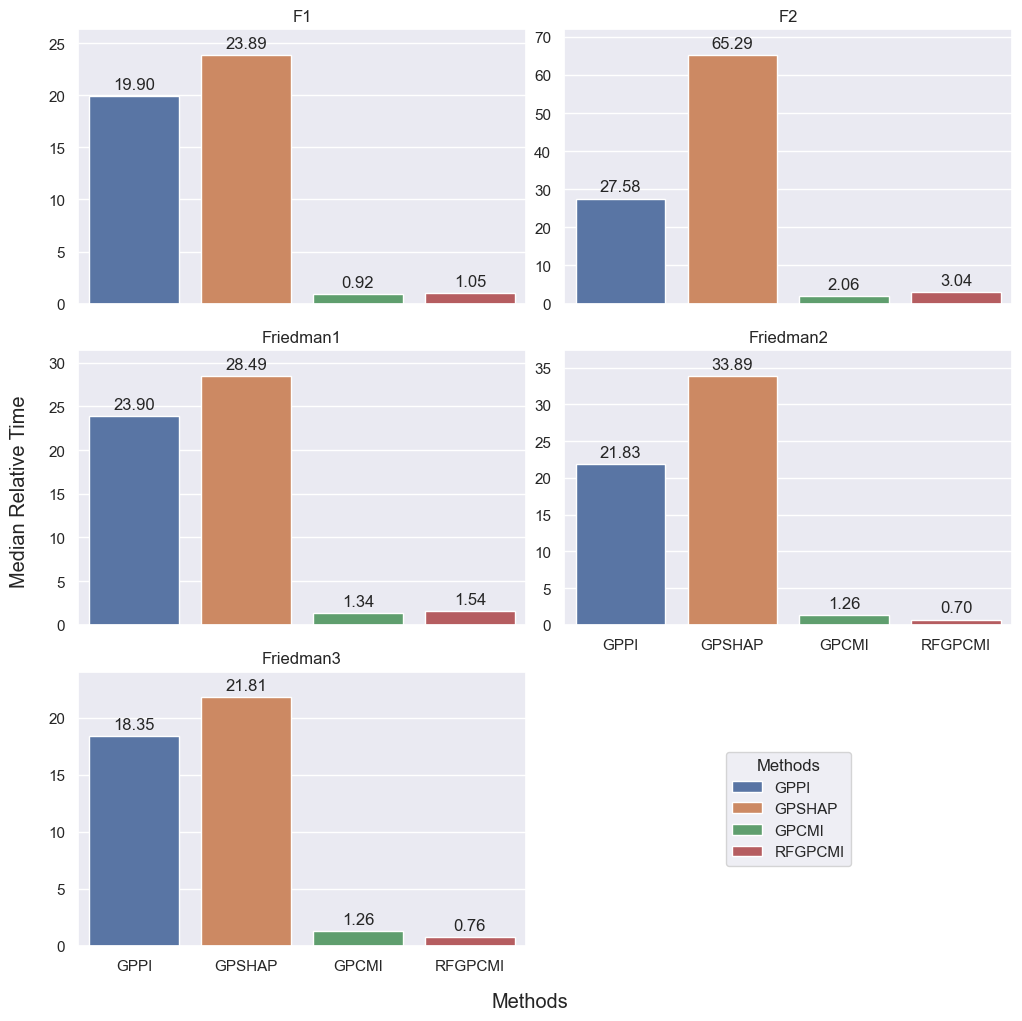

In [54]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    relative_time_df, 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

fig.figure.set_size_inches(10, 10)
fig.tight_layout(w_pad=0.5)

fig.supxlabel("Methods", x=0.5, y=-0.02)
fig.supylabel("Median Relative Time", x=-0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True)
axes[5].axis('off')

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods"
)

plt.show()

In [57]:
a = median_loss[:, :, "training_losses"] / relative_time_df.median()
a = a.to_frame().T

In [60]:
idx = pd.IndexSlice
a.loc[:, idx[:, methods]]

dataset,F1,F2,Friedman1,Friedman2,Friedman3,F1,F2,Friedman1,Friedman2,Friedman3,F1,F2,Friedman1,Friedman2,Friedman3,F1,F2,Friedman1,Friedman2,Friedman3
method,GPPI,GPPI,GPPI,GPPI,GPPI,GPSHAP,GPSHAP,GPSHAP,GPSHAP,GPSHAP,GPCMI,GPCMI,GPCMI,GPCMI,GPCMI,RFGPCMI,RFGPCMI,RFGPCMI,RFGPCMI,RFGPCMI
0,0.000003,0.000009,0.00498,0.001093,0.001044,0.000002,0.000006,0.004061,0.000704,0.004469,0.000035,0.000125,0.066371,0.018934,0.015164,1.275482e-07,0.000122,0.052591,0.033489,0.025097


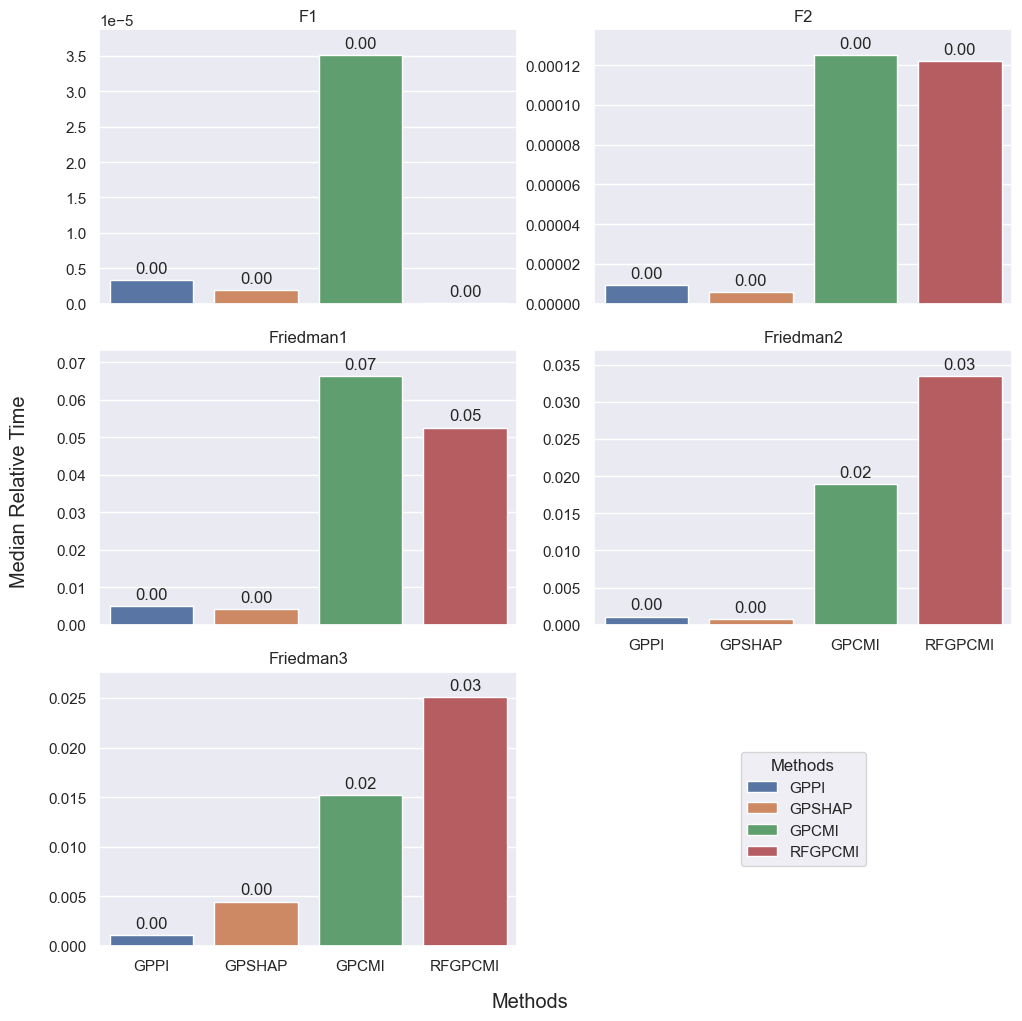

In [59]:
# Plotting relative performance of each method compared to GP for each dataset
fig, axes = plot_results(
    a.loc[:, idx[:, methods]], 
    nrows=3, 
    ncols=2, 
    subplot_kwargs={"sharex": True},
    group_level="dataset",
    value_level=None, 
    value_key=None,
    plotting_function=lambda data, ax: sns.barplot(data=data, ax=ax),
)

fig.figure.set_size_inches(10, 10)
fig.tight_layout(w_pad=0.5)

fig.supxlabel("Methods", x=0.5, y=-0.02)
fig.supylabel("Median Relative Time", x=-0.02, y=0.5)

axes[3].tick_params(axis='x', labelbottom=True)
axes[5].axis('off')

# Add value labels on top of each bar and adjust y-axis limits for better visibility
for ax in axes[:5]:
    base_padding = 3
    margin_ratio = 0.05

    bottom, top = ax.get_ylim()
    y_padding = margin_ratio * (top - bottom)

    new_top = top + (y_padding if top else 0)
    new_bottom = bottom - (y_padding if bottom else 0)
    ax.set_ylim(new_bottom, new_top)

    for container in ax.containers:
        v = container.datavalues[0]
        adjusted_padding = base_padding if (v != 0) or (top > 0) else -(11 + base_padding)
        ax.bar_label(container, fmt='%.2f', padding=adjusted_padding)

# Take the legend handles and labels from the fifth subplot
handles = axes[4].containers
labels = [text.get_text() for text in axes[4].get_xticklabels()]

# Add the common legend to the empty subplot, centered
axes[5].legend(
    handles=handles, 
    labels=labels, 
    loc='center', 
    title="Methods"
)

for ax in axes[:5]:
    ax.set_yscale('linear')

plt.show()